# Initail Setup

In [2]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from iblatlas.regions import BrainRegions
from iblatlas.plots import plot_scalar_on_slice
from iblatlas.atlas import AllenAtlas
from iblatlas.flatmaps import FlatMap
from iblatlas.plots import plot_swanson_vector
from iblatlas.plots import plot_scalar_on_flatmap
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from scipy import stats
from scipy.signal import butter, filtfilt
import pickle
import matplotlib as mpl
from brainbox.ephys_plots import image_fr_plot
from iblutil.numerical import bincount2D

In [8]:
# Candidate sessions:

# subject = "UCLA_037"
# eid = "bda2faf5-9563-4940-a80f-ce444259e47b"
# pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"

In [ ]:
# Define Constants / Configuration
CONFIG = {
    'REVISION': '2024-05-06', 
    'TASK_EXCLUDE_WINDOW_PRE': 0.2, 
    'TASK_EXCLUDE_WINDOW_POST': 0.5,
    'LP_FILTER_HZ': 20,
    'MAX_SESSIONS_TO_PROCESS': None, 
    'CCG_BIN_SIZE': 0.001, 
    'CCG_WINDOW_SIZE': 0.2,
    'COUPLING_METHOD': 'sta', # 'correlation' or 'sta'
}

In [4]:
# Define and create project paths
base_path = Path(r"C:/Users/Experiment/Documents/Amirreza/SeqProject2026")
path_data = base_path / "data"
path_fig = base_path / "results" / "figures"
path_data_processed = path_data / "processed"
ibl_cache = path_data / 'raw'

# Create directories
for p in [ibl_cache, path_fig, path_data_processed]:
    p.mkdir(exist_ok=True, parents=True)

print(f"Directories ready. Cache: {ibl_cache}")

# Setup the ONE API with custom cache directory
try:
    one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True, cache_dir=ibl_cache)
    print("ONE API initialized.")
except Exception as e:
    print(f"Error initializing ONE: {e}")

# Setup AllenAtlas
ba = AllenAtlas()

Directories ready. Cache: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\data\raw
ONE API initialized.


# Session Selection, Download and Load

In [5]:
tag = '2025_Q3_IBL_et_al_BWM' # 'RepeatedSite'
brain_acronym = 'VISp'

# query sessions endpoint
sessions = one.search(tag=tag, atlas_acronym=brain_acronym, query_type='remote')
print(f'No. of detected sessions: {len(sessions)}')

# query insertions endpoint
insertions = one.search_insertions(tag=tag, atlas_acronym=brain_acronym)
print(f'No. of detected insertions: {len(insertions)}')

No. of detected sessions: 62
No. of detected insertions: 67


In [ ]:
# Define the Probe Insertion ID (PID)
pid = "c9664185-d3fd-4e0e-89cf-77c402038938"
print(f"\nProcessing PID: {pid}")

# Initialize SpikeSortingLoader
ssl = SpikeSortingLoader(pid=pid, one=one, atlas=ba)
print(f"Session ID (EID): {ssl.eid}")
print(f"Probe Name: {ssl.pname}")

# Load Spiking Neural Data (Spikes, Clusters, Channels)
# load_spike_sorting() downloads and loads the data efficiently
spikes, clusters, channels = ssl.load_spike_sorting()

# IMPORTANT: Merge clusters with channel data to get brain region acronyms and coordinates
clusters = ssl.merge_clusters(spikes, clusters, channels)

print(f"Spikes loaded: {spikes.times.shape[0]} spikes")
if 'acronym' in clusters:
    print(f"Cluster regions found: {set(clusters.acronym)}")

# Load Trial Data using SessionLoader
sl = SessionLoader(eid=ssl.eid, one=one)
sl.load_trials()
print(f"Trials loaded. Found keys: {list(sl.trials.keys())}")
sl.load_wheel()
print(f"Wheel data loaded. Found keys: {list(sl.wheel.keys())}")
sl.load_pose(views=['left', 'right'])
print(f"Pose data loaded. Found keys: {list(sl.pose.keys())}")

# Initialize containers for pupil data
pupil_features = None
pupil_times = None
try:
    print("Loading leftCamera data (features and times)...")
    # Explicitly load camera object using ONE as per IBL documentation
    # This downloads _ibl_leftCamera.features.pqt and _ibl_leftCamera.times.npy
    # We assume 'sl' (SessionLoader) is defined in the environment
    left_camera = sl.one.load_object(sl.eid, 'leftCamera', collection='alf')
    
    # Check if we have the necessary attributes
    if hasattr(left_camera, 'features') and hasattr(left_camera, 'times'):
        pupil_features = left_camera.features
        pupil_times = left_camera.times
        print("Camera data loaded successfully.")
    else:
        print("Camera object loaded but 'features' or 'times' attribute missing.")

except Exception as e:
    print(f"Could not load pupil data: {e}")


Processing PID: c9664185-d3fd-4e0e-89cf-77c402038938
Session ID (EID): e349a2e7-50a3-47ca-bc45-20d1899854ec
Probe Name: probe01


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:414: ALFWarning: No default revision for dataset alf/probe01/pykilosort/#2024-03-12#/clusters.metrics.pqt; using most recent
  warnings.warn(


Spikes loaded: 28721702 spikes
Cluster regions found: {'VISp4', 'VISp2/3', 'VISp1', 'VISp5', 'ENTm3', 'ENTm1', 'ec', 'VISpl6a', 'VISp6a', 'ENTm2', 'void', 'ENTm5', 'HPF'}


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Trials loaded. Found keys: ['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume', 'firstMovement_times', 'intervals_0', 'intervals_1']
Wheel data loaded. Found keys: ['times', 'position', 'velocity', 'acceleration']


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2023-04-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Pose data loaded. Found keys: ['leftCamera', 'rightCamera']


# Behavioural Data

In [7]:
reaction_time = sl.trials['response_times'] - sl.trials['stimOn_times']

correct_trial_idx = sl.trials['feedbackType'] == 1
incorrect_trial_idx = sl.trials['feedbackType'] == -1
correct_reaction_time = np.mean(reaction_time[correct_trial_idx])
incorrect_reaction_time = np.mean(reaction_time[incorrect_trial_idx])

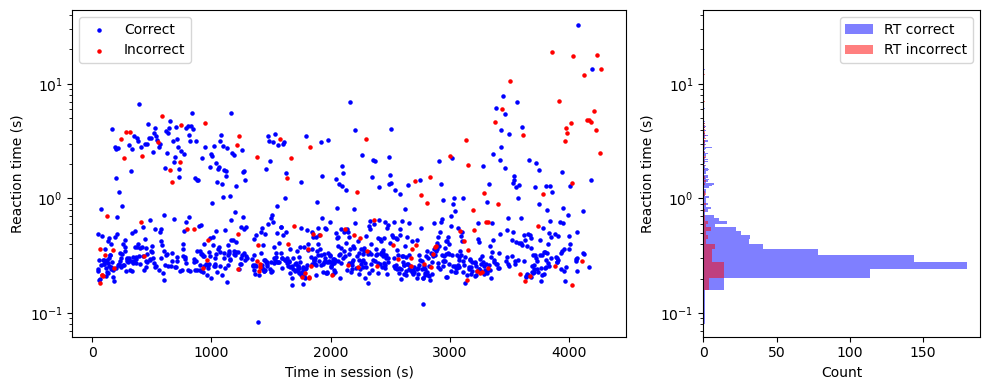

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})  # Adjust figsize as needed

# Scatter plot on the left (ax1)
ax1.scatter(sl.trials['stimOn_times'][correct_trial_idx], reaction_time[correct_trial_idx], c='blue', s=5, label='Correct')
ax1.scatter(sl.trials['stimOn_times'][incorrect_trial_idx], reaction_time[incorrect_trial_idx], c='red', s=5, label='Incorrect')
ax1.set_yscale("log")
ax1.set_xlabel('Time in session (s)')
ax1.set_ylabel('Reaction time (s)')
ax1.legend()

# Histogram on the right (ax2)
ax2.hist(reaction_time[correct_trial_idx], bins=np.linspace(0, 20, 500), color='blue', alpha=0.5, label='RT correct', orientation='horizontal')
ax2.hist(reaction_time[incorrect_trial_idx], bins=np.linspace(0, 20, 500), color='red', alpha=0.5, label='RT incorrect', orientation='horizontal')
ax2.legend()
ax2.set_xlabel('Count')
ax2.set_ylabel('Reaction time (s)')
ax2.set_yscale("log")
ax2.set_ylim(ax1.get_ylim())  # Sync y-axis limits with scatter plot

plt.tight_layout()  # Adjust spacing between subplots
#To see the output, run the code.

# Single Trial Raster Plots

In [ ]:
# Update CONFIG with Raster Plot constants
CONFIG.update({
    'RASTER_TRIAL_IDX': 563,          # The specific trial index to plot
    'RASTER_WINDOW_PRE': 1,           # Seconds before Stim On
    'RASTER_WINDOW_POST': 2,          # Seconds after Feedback
    'RASTER_ONLY_GOOD_UNITS': True,   # Set to False to plot ALL neurons
    'RASTER_ALIGN_TO_STIM_ON': True,  # Set True to make Stim On = 0s, False for Session Time
})


# Flag to save the figure (Standalone variable, not in CONFIG)
SAVE_FIGURE = True

Loading leftCamera data (features and times)...


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-06-04", "2025-05-31"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Camera data loaded successfully.
Pupil data found in window: 249 frames.
Figure saved to: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\results\figures\c9664185-d3fd-4e0e-89cf-77c402038938_563_Raster.png


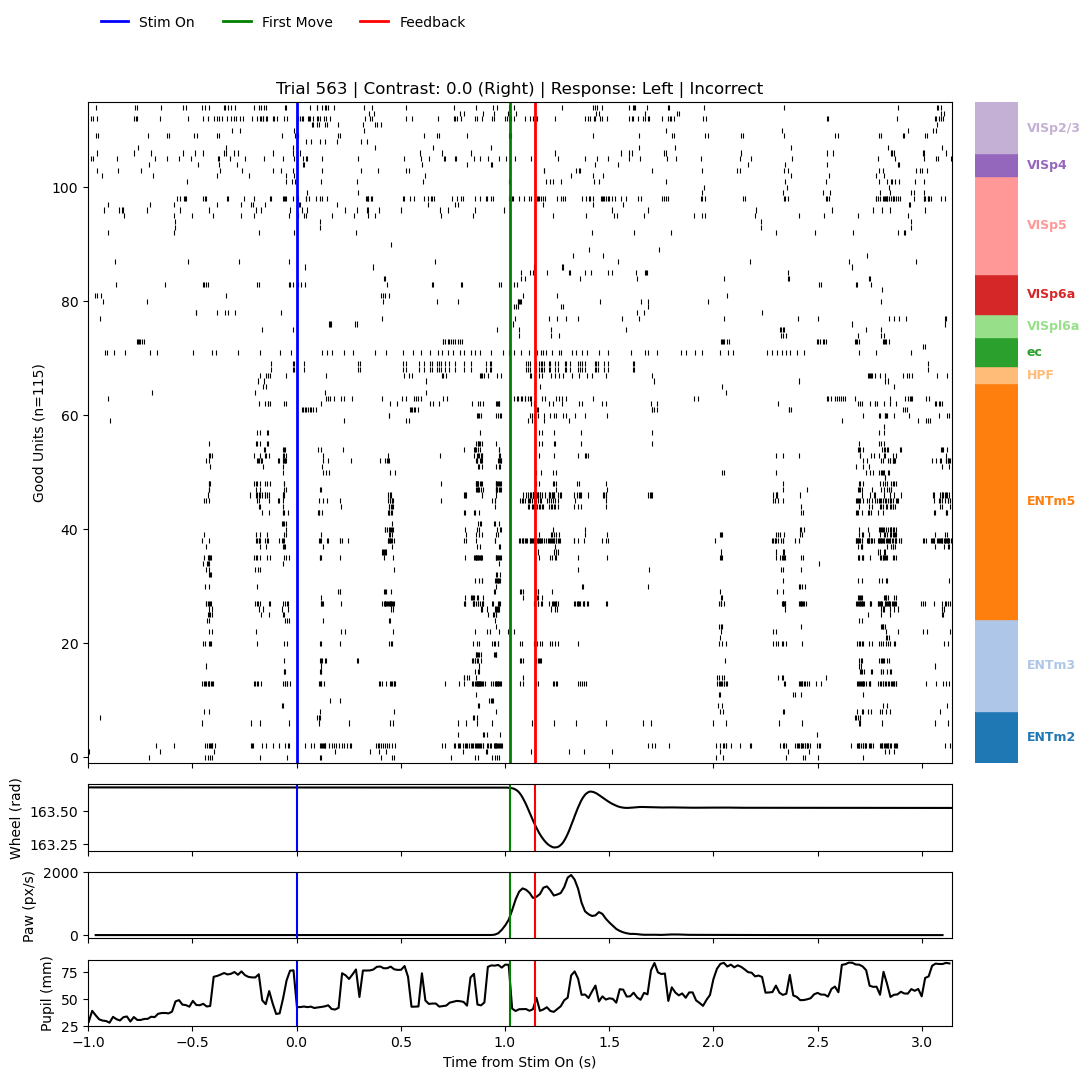

In [ ]:
trial_idx = CONFIG['RASTER_TRIAL_IDX']

# Ensure 'sl' (SessionLoader) is defined in your environment
t_stim_on = sl.trials['stimOn_times'][trial_idx]
t_first_move = sl.trials['firstMovement_times'][trial_idx]
t_feedback = sl.trials['feedback_times'][trial_idx]

# Define the absolute time window for data filtering
t_start = t_stim_on - CONFIG['RASTER_WINDOW_PRE']
t_end = t_feedback + CONFIG['RASTER_WINDOW_POST']

# Determine Alignment Offset
if CONFIG['RASTER_ALIGN_TO_STIM_ON']:
    t_offset = t_stim_on
    xlabel_text = 'Time from Stim On (s)'
else:
    t_offset = 0
    xlabel_text = 'Time in session (s)'

# --- Retrieve Trial Metadata for Title ---
# Handle contrast (check for NaN to determine side)
cont_l = sl.trials['contrastLeft'][trial_idx]
cont_r = sl.trials['contrastRight'][trial_idx]

if not np.isnan(cont_l):
    contrast_val = cont_l
    stim_side = 'Left'
elif not np.isnan(cont_r):
    contrast_val = cont_r
    stim_side = 'Right'
else:
    contrast_val = 0
    stim_side = 'Zero'

# Handle Choice (-1: Right, 1: Left, 0: NoGo)
choice_map = {1: 'Left', -1: 'Right', 0: 'NoGo'}
choice_val = sl.trials['choice'][trial_idx]
response_str = choice_map.get(choice_val, str(choice_val))

# Handle Feedback (1: Correct, -1: Incorrect)
fb_val = sl.trials['feedbackType'][trial_idx]
outcome_str = 'Correct' if fb_val == 1 else 'Incorrect'

plot_title = f"Trial {trial_idx} | Contrast: {contrast_val} ({stim_side}) | Response: {response_str} | {outcome_str}"


# 2. Process Spike Data
# Select units based on configuration
if CONFIG['RASTER_ONLY_GOOD_UNITS']:
    # Filter for "good" clusters only (label == 1)
    target_indices = np.where(clusters.label == 1)[0]
    ylabel_text = f'Good Units (n={len(target_indices)})'
else:
    # Use all clusters
    target_indices = np.arange(len(clusters.label))
    ylabel_text = f'All Units (n={len(target_indices)})'

# Create a DataFrame for easier sorting/grouping
df_units = pd.DataFrame({
    'id': target_indices,
    'acronym': clusters.acronym[target_indices],
    'depth': clusters.depths[target_indices]
})

# Sort by depth ASCENDING (Deep -> Surface)
df_units = df_units.sort_values(by='depth', ascending=True).reset_index(drop=True)

# Map acronyms to colors for the sidebar
unique_regions = df_units['acronym'].unique()
region_colors = {reg: plt.cm.tab20(i % 20) for i, reg in enumerate(unique_regions)}
region_colors['void'] = 'black'

# Filter spikes for the time window GLOBALLY first (using absolute times)
mask_window = (spikes.times >= t_start) & (spikes.times <= t_end)
window_spike_times = spikes.times[mask_window]
window_spike_clusters = spikes.clusters[mask_window]

# 3. Process Behavioral Data
# --- Wheel Data ---
mask_wheel = (sl.wheel['times'] >= t_start) & (sl.wheel['times'] <= t_end)
wheel_t = sl.wheel['times'][mask_wheel]
wheel_pos = sl.wheel['position'][mask_wheel]

# --- Paw Speed Data ---
pose_t = None
paw_speed = None
if hasattr(sl, 'pose') and 'leftCamera' in sl.pose:
    pose_df = sl.pose['leftCamera']
    if 'times' in pose_df.columns:
        pose_timestamps = pose_df['times'].values
    else:
        pose_timestamps = pose_df.index.values

    mask_pose = (pose_timestamps >= t_start) & (pose_timestamps <= t_end)
    pose_t = pose_timestamps[mask_pose]
    
    # Calculate Speed
    paw_key = 'paw_r' if 'paw_r_x' in pose_df.columns else 'paw_l'
    if f'{paw_key}_x' in pose_df.columns:
        dx = np.gradient(pose_df[f'{paw_key}_x'].values[mask_pose])
        dy = np.gradient(pose_df[f'{paw_key}_y'].values[mask_pose])
        dt = np.gradient(pose_t)
        dt[dt == 0] = np.nan
        speed_raw = np.sqrt(dx**2 + dy**2) / dt
        paw_speed = pd.Series(speed_raw).fillna(0).rolling(window=5, center=True).mean().values

# --- Pupil Diameter Data ---
pupil_t = None
pupil_diam = None

if pupil_features is not None and pupil_times is not None:
    # Identify the correct diameter column
    diam_col = 'pupilDiameter_raw'
    
    if diam_col in pupil_features.columns:
        # Handle potential length mismatch (though unlikely in valid datasets)
        n_frames = min(len(pupil_times), len(pupil_features))
        
        # Slice valid data
        pt = pupil_times[:n_frames]
        pd_vals = pupil_features[diam_col].values[:n_frames]
        
        # Filter for the trial window
        mask_pupil = (pt >= t_start) & (pt <= t_end)
        pupil_t = pt[mask_pupil]
        pupil_diam = pd_vals[mask_pupil]
        print(f"Pupil data found in window: {len(pupil_t)} frames.")

# 4. Generate Plot
fig = plt.figure(figsize=(12, 12)) # Increased height for extra plot
# Adjusted height_ratios to make behavioral plots smaller [Raster, Wheel, Paw, Pupil]
gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], height_ratios=[10, 1, 1, 1], wspace=0.05, hspace=0.1)

# -- Raster Plot (Top Left) --
ax_raster = fig.add_subplot(gs[0, 0])

# Iterate through sorted units and plot using vlines (adjusting for offset)
for y_idx, row in df_units.iterrows():
    unit_spike_times = window_spike_times[window_spike_clusters == row['id']]
    if len(unit_spike_times) > 0:
        # Subtract offset to align relative to stim on if requested
        ax_raster.vlines(unit_spike_times - t_offset, y_idx - 0.45, y_idx + 0.45, color='k', linewidth=0.8)

# Events (Adjusted for offset)
for ax in [ax_raster]:
    ax.axvline(t_stim_on - t_offset, color='blue', linestyle='-', linewidth=2, label='Stim On')
    ax.axvline(t_first_move - t_offset, color='green', linestyle='-', linewidth=2, label='First Move')
    ax.axvline(t_feedback - t_offset, color='red', linestyle='-', linewidth=2, label='Feedback')

# Set Limits relative to offset
ax_raster.set_xlim(t_start - t_offset, t_end - t_offset)
ax_raster.set_ylim(-1, len(df_units))
ax_raster.set_ylabel(ylabel_text)
ax_raster.set_title(plot_title)
# Hide x-axis labels for raster
ax_raster.tick_params(labelbottom=False)

# -- Region Color Bar (Top Right) --
ax_regions = fig.add_subplot(gs[0, 1])
y_min = 0
for acronym, group in df_units.groupby('acronym', sort=False):
    count = len(group)
    color = region_colors.get(acronym, 'gray')
    ax_regions.add_patch(plt.Rectangle((0, y_min), 1, count, color=color))
    ax_regions.text(1.2, y_min + count/2, acronym, va='center', fontsize=9, color=color, fontweight='bold')
    y_min += count

ax_regions.set_ylim(0, len(df_units))
ax_regions.axis('off')

# -- Wheel Position (2nd Row) --
ax_wheel = fig.add_subplot(gs[1, 0], sharex=ax_raster)
ax_wheel.plot(wheel_t - t_offset, wheel_pos, color='black')
ax_wheel.set_ylabel('Wheel (rad)')
ax_wheel.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_wheel.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_wheel.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_wheel.tick_params(labelbottom=False)

# -- Paw Speed (3rd Row) --
ax_paw = fig.add_subplot(gs[2, 0], sharex=ax_raster)
if paw_speed is not None:
    ax_paw.plot(pose_t - t_offset, paw_speed, color='black')
else:
    ax_paw.text(0.5, 0.5, "Paw data not available", ha='center', transform=ax_paw.transAxes)

ax_paw.set_ylabel('Paw (px/s)')
ax_paw.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_paw.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_paw.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_paw.tick_params(labelbottom=False)

# -- Pupil Diameter (4th Row) --
ax_pupil = fig.add_subplot(gs[3, 0], sharex=ax_raster)
if pupil_diam is not None:
    ax_pupil.plot(pupil_t - t_offset, pupil_diam, color='black')
else:
    ax_pupil.text(0.5, 0.5, "Pupil data not available", ha='center', transform=ax_pupil.transAxes)

ax_pupil.set_ylabel('Pupil (mm)')
ax_pupil.set_xlabel(xlabel_text)
ax_pupil.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_pupil.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_pupil.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_pupil.tick_params(labelbottom=True)

# Legend
lines = [
    plt.Line2D([0], [0], color='blue', linewidth=2),
    plt.Line2D([0], [0], color='green', linewidth=2),
    plt.Line2D([0], [0], color='red', linewidth=2)
]
ax_raster.legend(lines, ['Stim On', 'First Move', 'Feedback'], loc='upper left', frameon=False, bbox_to_anchor=(0, 1.15), ncol=3)

# Save the figure if requested
if SAVE_FIGURE:
    # Ensure 'pid' and 'path_fig' are defined in the environment
    # Filename format: PID_Trial ID_Raster
    filename = f"{pid}_{trial_idx}_Raster.png"
    save_path = path_fig / filename
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")

plt.show()